# Perceptron with Accuracy per Epoch and 4 Separate Plots

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
from google.colab import files

print("Please upload the  file:")
files.upload()

Please upload the 'Q2_data.csv' file:


Saving A5_P1.csv to A5_P1 (1).csv


{'A5_P1 (1).csv': b'X1,X2,y\n2.496714153011233,1.8617356988288154,1.0\n2.6476885381006925,3.5230298564080256,1.0\n1.765846625276664,1.7658630430508195,1.0\n3.5792128155073915,2.767434729152909,1.0\n1.5305256140650478,2.5425600435859645,1.0\n1.5365823071875377,1.534270246429743,1.0\n2.241962271566034,0.08671975534220211,1.0\n0.27508216748696723,1.4377124707590272,1.0\n0.9871688796655762,2.314247332595274,1.0\n1.0919759244787892,0.5876962986647085,1.0\n-0.534351231078446,-2.225776300486536,0.0\n-1.9324717953120762,-3.424748186213457,0.0\n-2.5443827245251827,-1.889077410290134,0.0\n-3.1509935774223026,-1.624301981654328,0.0\n-2.6006386899188048,-2.291693749793277,0.0\n-2.601706612229397,-0.14772181549106222,0.0\n-2.013497224737934,-3.0577109289559004,0.0\n-1.1774550878968109,-3.2208436499710222,0.0\n-1.7911364049952445,-3.959670123879776,0.0\n-3.3281860488984307,-1.8031387641308765,0.0\n'}

In [8]:
data = pd.read_csv('A5_P1.csv')

X = data[['X1', 'X2']].values
y = data['y'].values

print("Data Loaded Successfully")

Data Loaded Successfully


In [9]:
def initialize_weights(input_dim):
    return np.random.rand(input_dim + 1)

def step_activation(z):
    return np.where(z >= 0, 1, 0)

def compute_accuracy(X, y, weights):
    correct = 0
    for i in range(len(X)):
        x_i = np.append(1, X[i])
        pred = step_activation(np.dot(x_i, weights))
        if pred == y[i]:
            correct += 1
    return correct / len(X)

In [10]:
def plotboundary(X, y, weights, title):
    plt.figure()

    plt.scatter(X[y == 0, 0], X[y == 0, 1])
    plt.scatter(X[y == 1, 0], X[y == 1, 1])

    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    if weights[2] != 0:
        y_vals = (-weights[0] - weights[1]*x_vals) / weights[2]
        plt.plot(x_vals, y_vals)

    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid()
    plt.show()

Epoch 1: Accuracy = 1.00
Epoch 2: Accuracy = 1.00
Epoch 3: Accuracy = 1.00
Epoch 4: Accuracy = 1.00
Epoch 5: Accuracy = 1.00


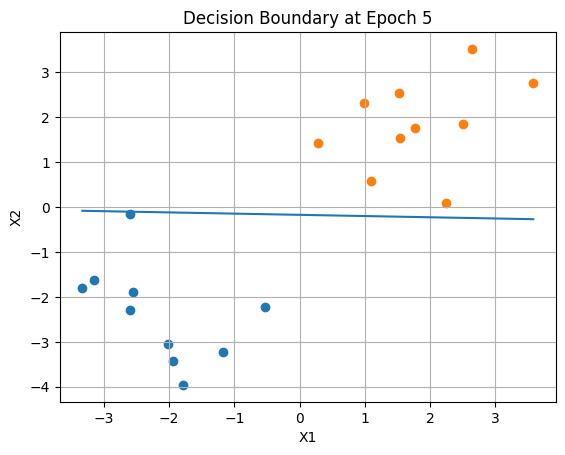

Epoch 6: Accuracy = 1.00
Epoch 7: Accuracy = 1.00
Epoch 8: Accuracy = 1.00
Epoch 9: Accuracy = 1.00
Epoch 10: Accuracy = 1.00


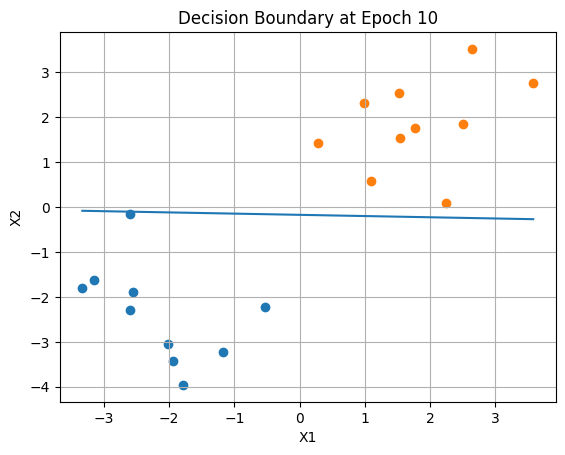

Epoch 11: Accuracy = 1.00
Epoch 12: Accuracy = 1.00
Epoch 13: Accuracy = 1.00
Epoch 14: Accuracy = 1.00
Epoch 15: Accuracy = 1.00


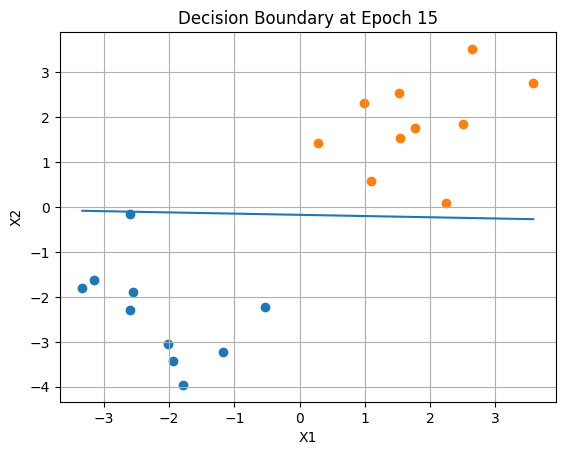

Epoch 16: Accuracy = 1.00
Epoch 17: Accuracy = 1.00
Epoch 18: Accuracy = 1.00
Epoch 19: Accuracy = 1.00
Epoch 20: Accuracy = 1.00


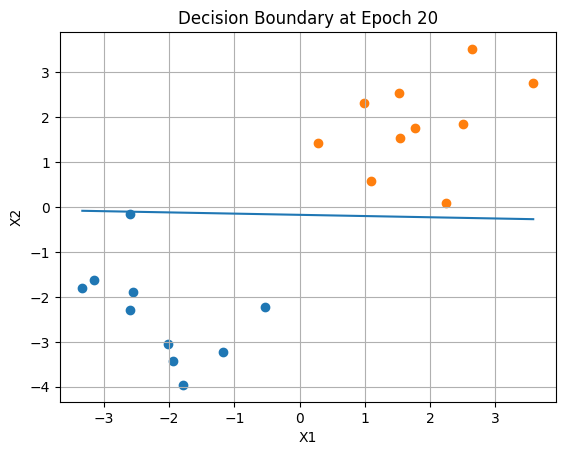

In [11]:
weights = initialize_weights(X.shape[1])

learning_rate = 0.01
epochs = 20

checkpoints = [5, 10, 15, 20]

for epoch in range(1, epochs + 1):
    for i in range(len(X)):
        x_i = np.append(1, X[i])
        prediction = step_activation(np.dot(x_i, weights))
        weights -= learning_rate * (prediction - y[i]) * x_i

    acc = compute_accuracy(X, y, weights)
    print(f"Epoch {epoch}: Accuracy = {acc:.2f}")

    if epoch in checkpoints:
        plotboundary(X, y, weights, f"Decision Boundary at Epoch {epoch}")

Question 8

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
iris = load_iris()
X = iris.data
y = iris.target

y_onehot = np.zeros((y.size, 3))
y_onehot[np.arange(y.size), y] = 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
input_size = 4
hidden_size = 5
output_size = 3

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

learning_rate = 0.01
epochs = 1000

In [55]:
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [56]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

In [57]:
train_losses = []
test_losses = []
train_acc = []
test_acc = []

for epoch in range(epochs):

    z1 = X_train @ W1 + b1
    a1 = tanh(z1)

    z2 = a1 @ W2 + b2
    a2 = softmax(z2)

    loss = mse(y_train, a2)
    train_losses.append(loss)

    train_acc.append(accuracy(y_train, a2))

    dz2 = (a2 - y_train)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    dz1 = (dz2 @ W2.T) * tanh_derivative(z1)
    dW1 = X_train.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    z1_test = X_test @ W1 + b1
    a1_test = tanh(z1_test)

    z2_test = a1_test @ W2 + b2
    a2_test = softmax(z2_test)

    test_losses.append(mse(y_test, a2_test))
    test_acc.append(accuracy(y_test, a2_test))

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}, Accuracy = {train_acc[-1]:.4f}")

Epoch 0: Loss = 0.4689, Accuracy = 0.1833
Epoch 100: Loss = 0.0099, Accuracy = 0.9833
Epoch 200: Loss = 0.0091, Accuracy = 0.9833
Epoch 300: Loss = 0.0087, Accuracy = 0.9833
Epoch 400: Loss = 0.0084, Accuracy = 0.9833
Epoch 500: Loss = 0.0081, Accuracy = 0.9833
Epoch 600: Loss = 0.0077, Accuracy = 0.9833
Epoch 700: Loss = 0.0074, Accuracy = 0.9833
Epoch 800: Loss = 0.0071, Accuracy = 0.9833
Epoch 900: Loss = 0.0067, Accuracy = 0.9917


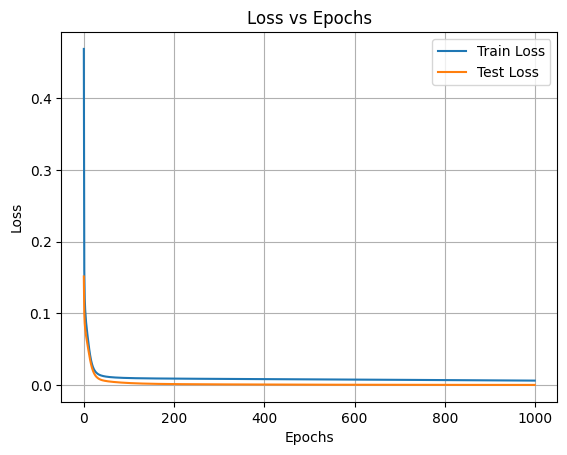

In [58]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

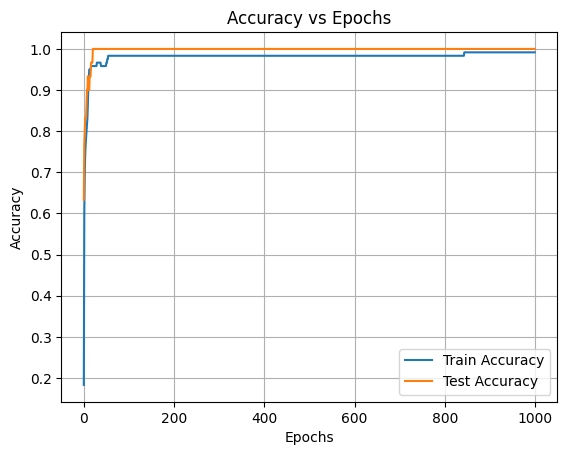

In [59]:
plt.figure()
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid()
plt.show()